### Disclaimer

Adapted from <https://colab.research.google.com/drive/1F02LMVM_kWJwDpynbCXhdxuqTWzQ51pZ?usp=sharing&utm_source=Google%20Colab>

### Installing Packages, Importing Libraries, Downloading & Using Dataset

In [ ]:
# Load libraries
import pandas as pd
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Export Graph as DotFile
from sklearn.tree import export_graphviz
# For using the DotFile
from six import StringIO
# Display the Tree as Image in Jupyter
from IPython.display import Image
# Convert DotFile to PNG
import pydotplus

In [ ]:
# Download & Save the dataset as pima.csv
!wget -O pima.csv "https://bit.ly/PimaIDD"

--2023-09-24 15:00:42--  https://bit.ly/PimaIDD
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv?utm_source=GitHub [following]
--2023-09-24 15:00:43--  https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv?utm_source=GitHub
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23105 (23K) [text/plain]
Saving to: ‘pima.csv’

pima.csv            100%[===================>]  22.56K  --.-KB/s    in 0.002s  

2023-09-24 15:00:43 (10.7 MB/s) - ‘pima.csv’ saved [23105/23105]



In [ ]:
# Load dataset
pima = pd.read_csv("pima.csv")
# Show amount of positive & negative diabetic patients in the dataset
print('❌ Non-Diabetic:', (pima['Outcome'] == 0).sum())
print('✅ Diabetic:', (pima['Outcome'] == 1).sum())

❌ Non-Diabetic: 500
✅ Diabetic: 268


###### <font size="5">👨🏻‍🏫</font> Train, Test on `DecisionTreeClassifier()`

In [ ]:
# Take all the columns of dataframe, except the last one ('Outcome')
feature_cols = pima.columns.values.tolist()[:-1]
X = pima[feature_cols]
# Store taraget variable for prediction in variable 'y'
y = pima.Outcome
print(f"{X}\n{'🔹'*10}\n{y}")

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
# 30% of data for test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=411)

###### <font size="5">🌲</font> Using `DecisionTreeClassifier()` & Visualization

In [ ]:
# Fit the training data
clf = DecisionTreeClassifier().fit(X_train,y_train)
# Predict test dataset
y_pred = clf.predict(X_test)

In [ ]:
import numpy as np
print(np.sum(y_test == 0))
np.sum(y_test == 1)

155


76

In [ ]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7056277056277056


The model is predicting both positives and negatives.

In [ ]:
metrics.confusion_matrix(y_test, y_pred)

array([[115,  40],
       [ 28,  48]])

The `plot_tree` function does not format the tree nicely.

In [ ]:
#from sklearn import tree
#tree.plot_tree(clf)

Get a nicely formated tree. The tree is rather big for easy inspection.

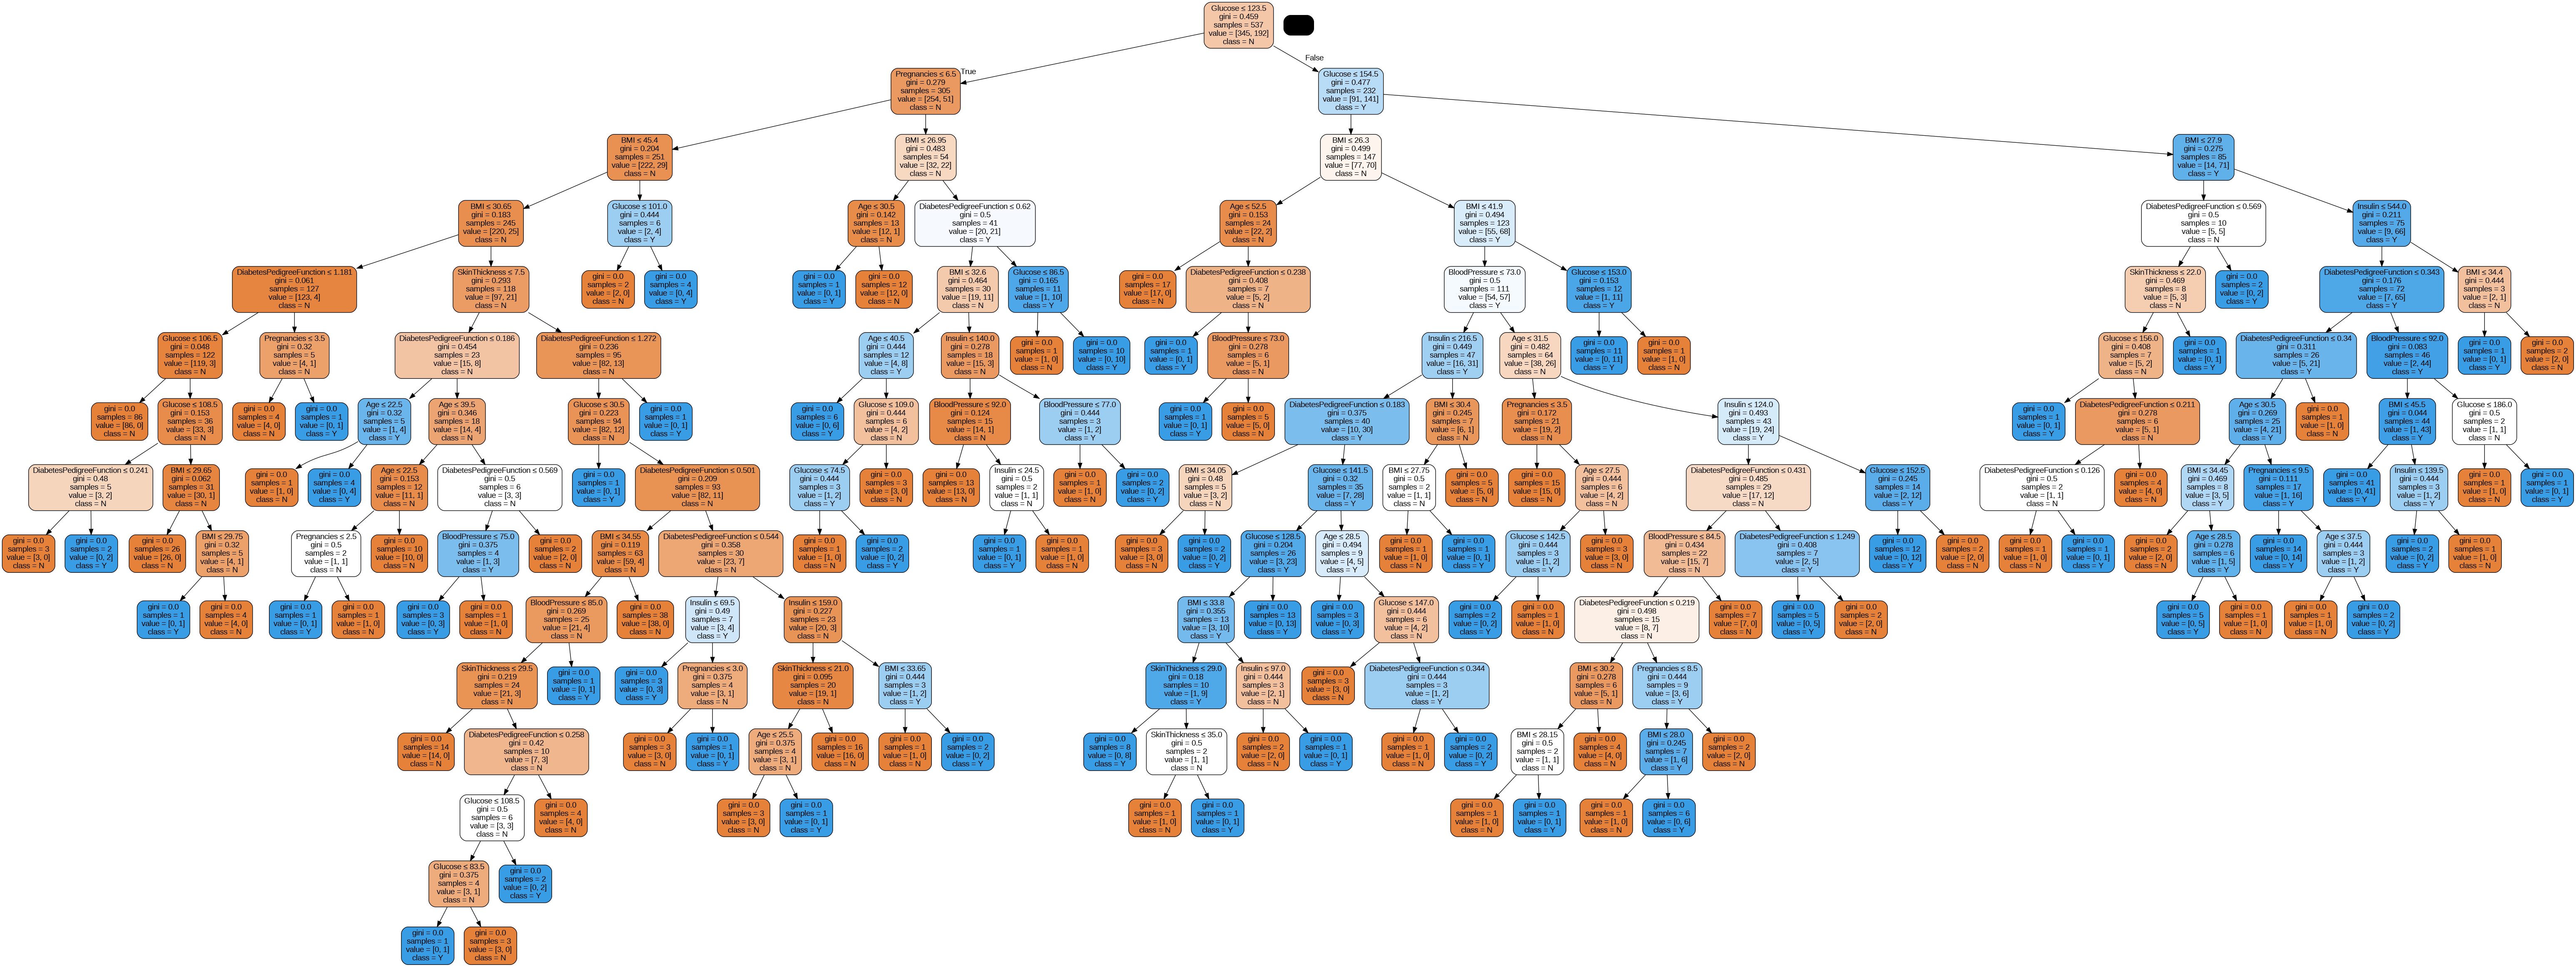

In [ ]:
# File-like access to IO Strings (build decision tree based on that)
dot_data = StringIO()
# Export graph
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols,
                class_names=['N', 'Y'])
# Gets the value of dot_data & converts it to graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Write the graph as png file
graph.write_png('diabetes.png')
# Call Image from IPython.display to show the image of DecisionTreeClassifier
Image(graph.create_png())

Train a pre-pruned tree with maximum depth = 4.

In [ ]:
# Fit the training data
# Using gini as Attribute Selection Measure, max_depth=3,
clf = DecisionTreeClassifier(criterion='gini', max_depth=4).fit(X_train,y_train)
# Predict test dataset
y_pred = clf.predict(X_test)

In [ ]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7142857142857143


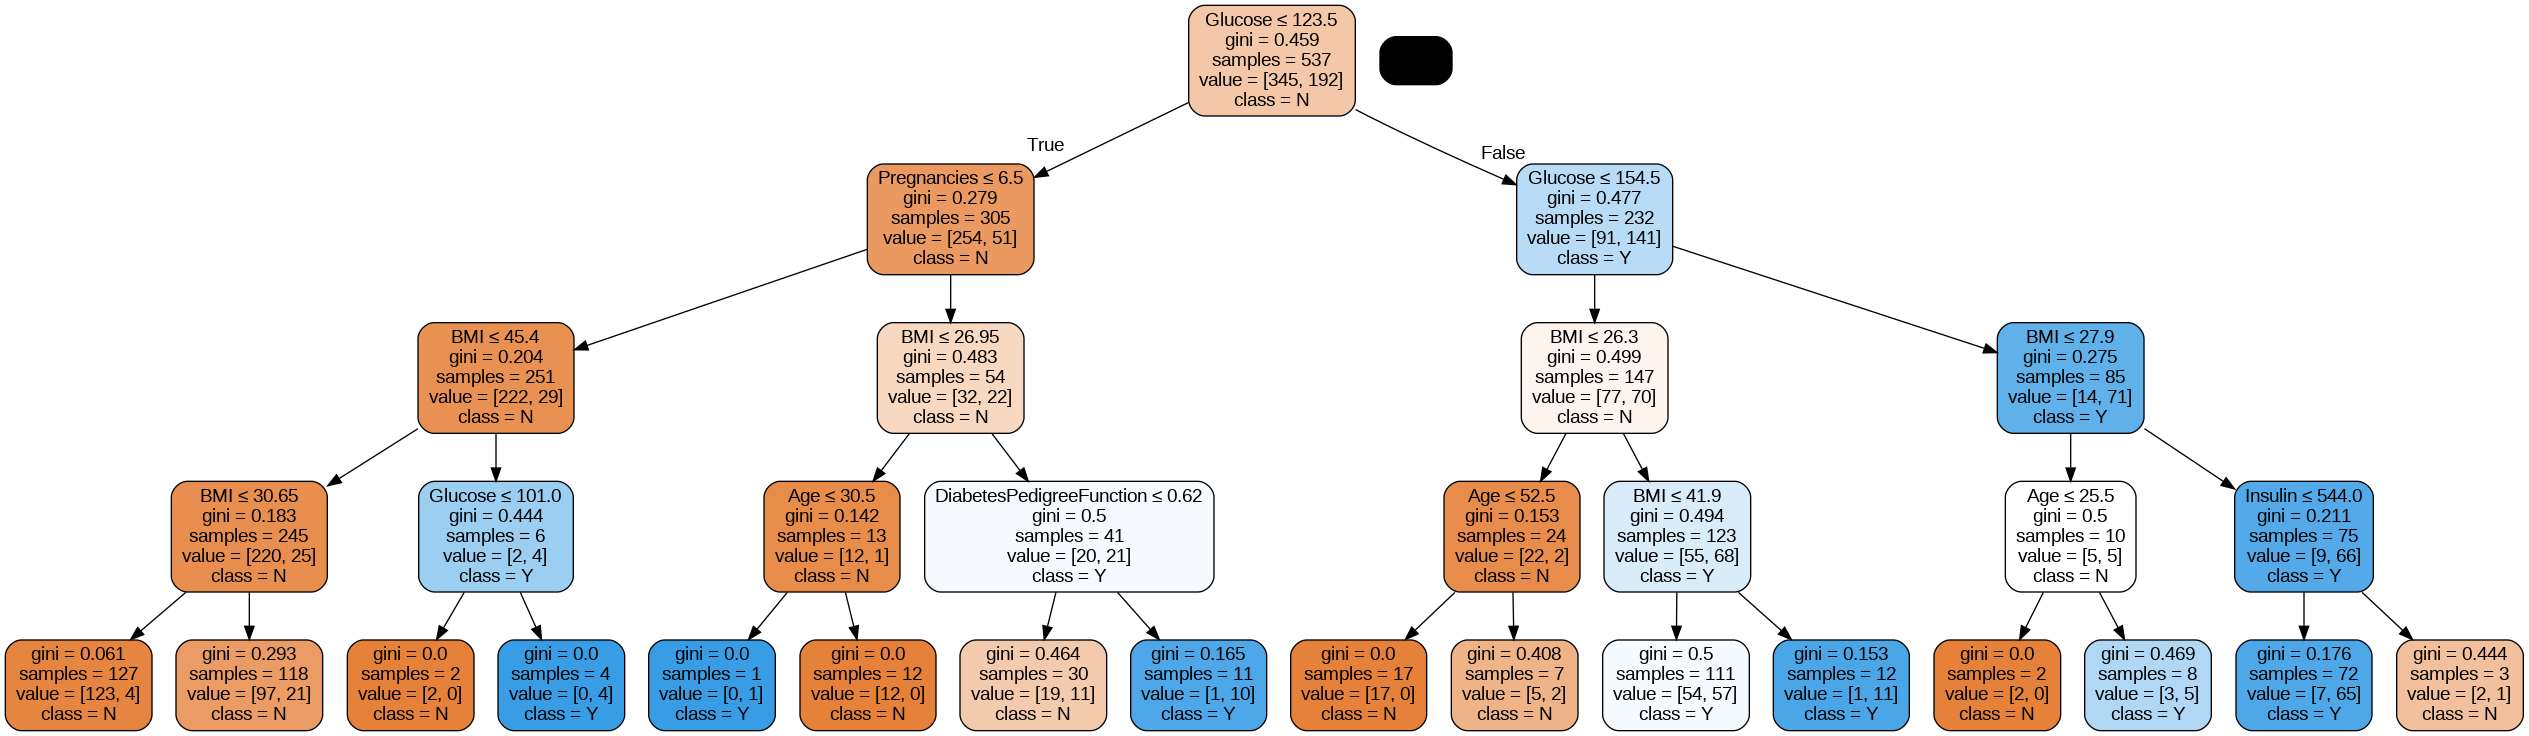

In [ ]:
# File-like access to IO Strings (build decision tree based on that)
dot_data = StringIO()
# Export graph
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols,
                class_names=['N', 'Y'])
# Gets the value of dot_data & converts it to graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Write the graph as png file
graph.write_png('diabetes.png')
# Call Image from IPython.display to show the image of DecisionTreeClassifier
Image(graph.create_png())

# Exercise

- Change the train/test split and re-learn the depth-4 tree. How similar? In terms of performance?
- To redo the split, either remove or change the random seed.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split()

ValueError: ignored

In [ ]:
clf = DecisionTreeClassifier(criterion='gini',)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

In [ ]:
# File-like access to IO Strings (build decision tree based on that)
dot_data = StringIO()
# Export graph
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols,
                class_names=['N', 'Y'])
# Gets the value of dot_data & converts it to graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Write the graph as png file
graph.write_png('diabetes.png')
# Call Image from IPython.display to show the image of DecisionTreeClassifier
Image(graph.create_png())

## Extract rules

In [ ]:
from sklearn.tree import export_text
print(export_text(clf))

|--- feature_1 <= 123.50
|   |--- feature_0 <= 6.50
|   |   |--- feature_5 <= 45.40
|   |   |   |--- feature_5 <= 30.65
|   |   |   |   |--- class: 0
|   |   |   |--- feature_5 >  30.65
|   |   |   |   |--- class: 0
|   |   |--- feature_5 >  45.40
|   |   |   |--- feature_1 <= 101.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  101.00
|   |   |   |   |--- class: 1
|   |--- feature_0 >  6.50
|   |   |--- feature_5 <= 26.95
|   |   |   |--- feature_7 <= 30.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_7 >  30.50
|   |   |   |   |--- class: 0
|   |   |--- feature_5 >  26.95
|   |   |   |--- feature_6 <= 0.62
|   |   |   |   |--- class: 0
|   |   |   |--- feature_6 >  0.62
|   |   |   |   |--- class: 1
|--- feature_1 >  123.50
|   |--- feature_1 <= 154.50
|   |   |--- feature_5 <= 26.30
|   |   |   |--- feature_7 <= 52.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_7 >  52.50
|   |   |   |   |--- class: 0
|   |   |--- feature_5 >  26.30
|   |   |   |--

Better with feature names:

In [ ]:
print(export_text(clf, feature_names=feature_cols))

|--- Glucose <= 123.50
|   |--- Pregnancies <= 6.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.65
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  30.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- Glucose <= 101.00
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  101.00
|   |   |   |   |--- class: 1
|   |--- Pregnancies >  6.50
|   |   |--- BMI <= 26.95
|   |   |   |--- Age <= 30.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  30.50
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.95
|   |   |   |--- DiabetesPedigreeFunction <= 0.62
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.62
|   |   |   |   |--- class: 1
|--- Glucose >  123.50
|   |--- Glucose <= 154.50
|   |   |--- BMI <= 26.30
|   |   |   |--- Age <= 52.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  52.50
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.30
|   |   |   |--- BMI <= 41.90
|   |   |   |   |--- class: 1
|  

Extract the rules and format them as logical implications (code from <https://mljar.com/blog/extract-rules-decision-tree/>).

In [ ]:
from sklearn.tree import _tree
def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []

    def recurse(node, path, paths):

        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]

    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]

    rules = []
    for path in paths:
        rule = "if "

        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]

    return rules


In [ ]:
rules = get_rules(clf, feature_cols, ['N','Y'])
for r in rules:
    print(r)

if (Glucose <= 123.5) and (Pregnancies <= 6.5) and (BMI <= 45.4) and (BMI <= 30.65) then class: N (proba: 96.85%) | based on 127 samples
if (Glucose <= 123.5) and (Pregnancies <= 6.5) and (BMI <= 45.4) and (BMI > 30.65) then class: N (proba: 82.2%) | based on 118 samples
if (Glucose > 123.5) and (Glucose <= 154.5) and (BMI > 26.3) and (BMI <= 41.9) then class: Y (proba: 51.35%) | based on 111 samples
if (Glucose > 123.5) and (Glucose > 154.5) and (BMI > 27.9) and (Insulin <= 544.0) then class: Y (proba: 90.28%) | based on 72 samples
if (Glucose <= 123.5) and (Pregnancies > 6.5) and (BMI > 26.95) and (DiabetesPedigreeFunction <= 0.62) then class: N (proba: 63.33%) | based on 30 samples
if (Glucose > 123.5) and (Glucose <= 154.5) and (BMI <= 26.3) and (Age <= 52.5) then class: N (proba: 100.0%) | based on 17 samples
if (Glucose > 123.5) and (Glucose <= 154.5) and (BMI > 26.3) and (BMI > 41.9) then class: Y (proba: 91.67%) | based on 12 samples
if (Glucose <= 123.5) and (Pregnancies > 6.5

# Exercise

- Upload a dataset, learn a tree, plot it and extract the rules.
- Use the CSV format.
- Limit the number of leaves of the tree.

In [ ]:
from google.colab import files

uploaded = files.upload()
filename, value = list(uploaded.items())[0]

In [ ]:
data = pd.read_csv(filename)
data

In [ ]:
feature_cols = data.columns.values.tolist()[:-1]
X = data[feature_cols]
y = data.RiskPerformance
X

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

In [ ]:
# File-like access to IO Strings (build decision tree based on that)
dot_data = StringIO()
# Export graph
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols,
                class_names=['N', 'Y'])
# Gets the value of dot_data & converts it to graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Write the graph as png file
graph.write_png('diabetes.png')
# Call Image from IPython.display to show the image of DecisionTreeClassifier
Image(graph.create_png())